In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage


In [2]:
data=pd.read_csv("hierarchical_clustering_dataset.csv")
data


,ID,Feature1,Feature2
0,1,2,3
1,2,3,2
2,3,2,4
3,4,8,8
4,5,9,9
5,6,8,7
6,7,25,24
7,8,24,26
8,9,26,25
9,10,40,41


In [4]:
X = data[[
    "Feature1",
    "Feature2"
]]
X

,Feature1,Feature2
0,2,3
1,3,2
2,2,4
3,8,8
4,9,9
5,8,7
6,25,24
7,24,26
8,26,25
9,40,41


In [5]:

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
     

In [7]:

clusters = kmeans.fit_predict(X)
data["Cluster"] = clusters

In [10]:
data["Cluster"] = clusters

for i in range(3):

    print("\n" + "="*50)
    print("CLUSTER", i + 1)
    print("="*50)

    cluster_data = data[
        data["Cluster"] == i
    ]

    print(
        cluster_data[
            [
                "Feature1",
                "Feature2"
            ]
        ]
    )

    print(
        "\nTotal Records :",
        len(cluster_data)
    )


CLUSTER 1
   Feature1  Feature2
0         2         3
1         3         2
2         2         4
3         8         8
4         9         9
5         8         7

Total Records : 6

CLUSTER 2
    Feature1  Feature2
12        60        60
13        61        58
14        59        61

Total Records : 3

CLUSTER 3
    Feature1  Feature2
6         25        24
7         24        26
8         26        25
9         40        41
10        42        40
11        41        42

Total Records : 6


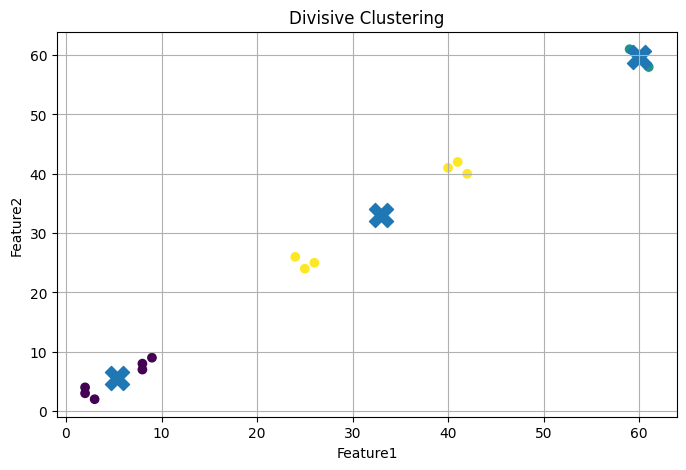

In [11]:
plt.figure(figsize=(8,5))

plt.scatter(
    X["Feature1"],
    X["Feature2"],
    c=clusters
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker="X"
)

plt.xlabel("Feature1")
plt.ylabel("Feature2")

plt.title("Divisive Clustering")

plt.grid(True)

plt.show()

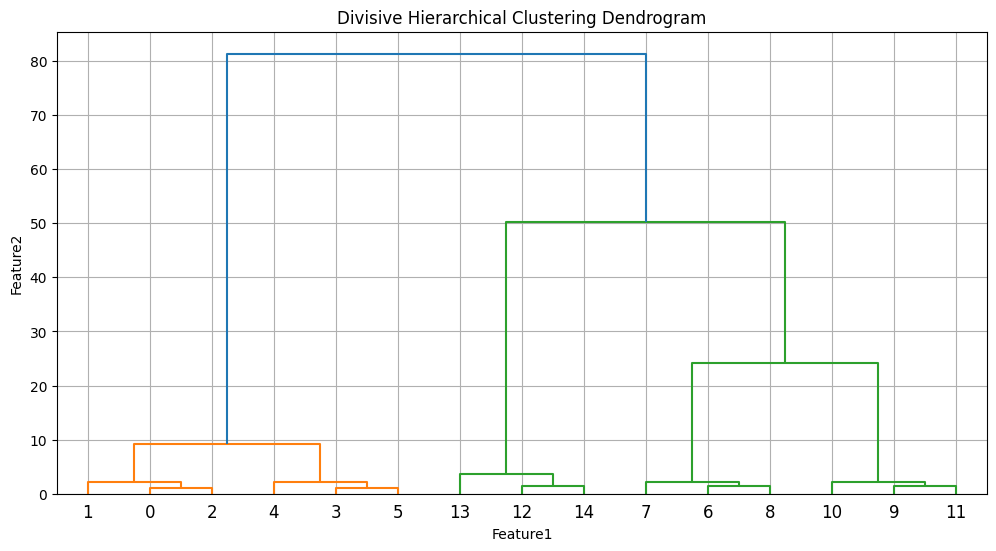

In [13]:

Z = linkage(
    X,
    method="complete"
)

plt.figure(figsize=(12,6))

dendrogram(Z)

plt.title("Divisive Hierarchical Clustering Dendrogram")
plt.xlabel("Feature1")
plt.ylabel("Feature2")

plt.grid(True)

plt.show()